# Name:Jakiel
# Date: 11-15-25
# Objective: Using Titanic Dataset to Predict a Continuous Target with Regression

# Section 1: Import and Inspect the Data


In [55]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [56]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Display a few records to verify
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Section 2. Data Exploration and Preparation for Regression Modelling


In [61]:
# Impute missing values for age with median
titanic.fillna({'age': titanic['age'].median()}, inplace=True) #titanic['age'].fillna(titanic['age'].median(), inplace=True)(recived error when trying to use with pandas 3.0)

# Drop rows with missing fare values
titanic = titanic.dropna(subset=['fare'])

# Create a new feature: family_size
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

titanic.head()

# Convert categorical features to numeric
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
titanic['class'] = titanic['class'].map({'First': 1, 'Second': 2, 'Third': 3})


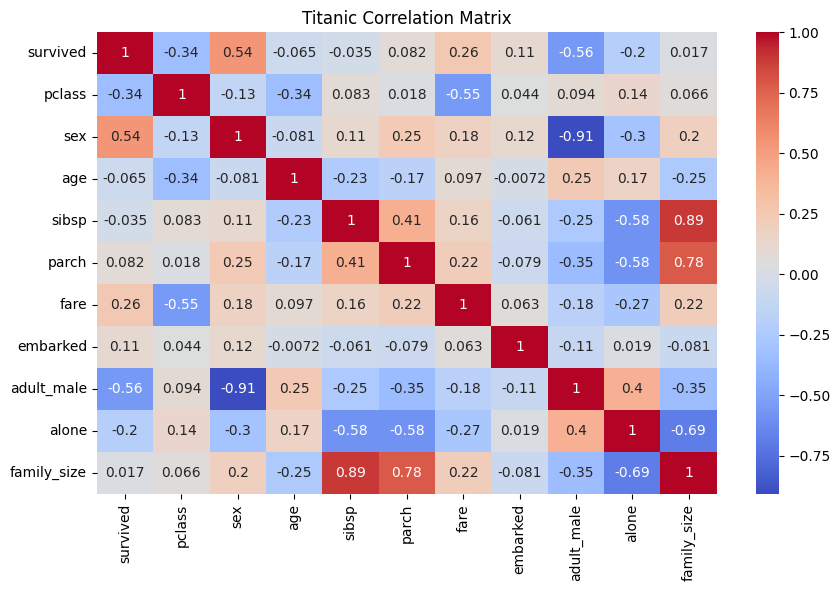

fare           1.000000
survived       0.257307
family_size    0.217138
parch          0.216225
sex            0.182333
sibsp          0.159651
age            0.096688
embarked       0.063462
adult_male    -0.182024
alone         -0.271832
pclass        -0.549500
Name: fare, dtype: float64

In [ ]:
# show correlation
titanic.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Titanic Correlation Matrix")
plt.show()

titanic.corr(numeric_only=True)['fare'].sort_values(ascending=False)


In [63]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,0,22.0,1,0,7.2500,0.0,3,man,True,NaN,Southampton,no,False,2
1,1,1,1,38.0,1,0,71.2833,1.0,1,woman,False,C,Cherbourg,yes,False,2
2,1,3,1,26.0,0,0,7.9250,0.0,3,woman,False,NaN,Southampton,yes,True,1
3,1,1,1,35.0,1,0,53.1000,0.0,1,woman,False,C,Southampton,yes,False,2
4,0,3,0,35.0,0,0,8.0500,0.0,3,man,True,NaN,Southampton,no,True,1


# Section 3. Feature Selection and Justification


In [5]:
# Case 1 : Age only
X1 = titanic[['age']]
Y1 = titanic['fare']

In [6]:
# Case 2: Family Size Only
X2 = titanic[['family_size']]
Y2 = titanic['fare']

In [7]:
# Case 3: Age and Family Size
X3 = titanic[['age', 'family_size']]
Y3 = titanic['fare']

In [8]:
#Case 4: Sex, Embarked, and Class
X4 = titanic[['sex', 'embarked', 'class']]
Y4 = titanic['fare']

Reflection Questions 3:

1. Why might these features affect a passenger’s fare:
   
   Age can affect a passengers fare due to seniors and children typically having cheaper prices.
   Family Size can affect the price since addition members are an additional ticket.
   Embarked can affect the fare price due destination distance and even the cost of maintaining each port which may affect how fare prices are set.
   

2. List all available features:
   Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'family_size'],
      dtype='object')

3. Which other features could improve predictions and why:
    Class is direclty related to fare price. 1st class fares would be the most expensive in relation to the others.

    Decks may have different aspects that can alter the fare like, view, easier access to a certain amenities. 

4. How many variables are in your Case 4:
   3

5. Which variable(s) did you choose for Case 4 and why do you feel those could make good inputs: 

    class, embarked and sex

    I selected these features as class has a direct relationship with fare price in most situation since you are paying for comfort and add-ons.
    Sex I believe that men and woman have different spending habits and value different things.


# Section 4. Train a Regression Model (Linear Regression)


In [9]:
# 4.1  Split the data into training and testing sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, Y1, test_size=0.2, random_state=123)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=123)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, Y3, test_size=0.2, random_state=123)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, Y4, test_size=0.2, random_state=123)

In [ ]:
# 4.2 Train Linear Regression Models for each case
lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train) # reran after handling missing values in next cell

In [11]:
# show how many missing values per column (for X4_train)
print(X4_train.isnull().sum().sort_values(ascending=False))
print("Total missing:", X4_train.isnull().sum().sum())
#since its only 2 rows with missing values i will drop them
X4_train = X4_train.dropna()
y4_train = y4_train[X4_train.index]

embarked    2
sex         0
class       0
dtype: int64
Total missing: 2


In [ ]:
# Predictions

y_pred_train1 = lr_model1.predict(X1_train)
y_pred_test1 = lr_model1.predict(X1_test)

y_pred_train2 = lr_model2.predict(X2_train)
y_pred_test2 = lr_model2.predict(X2_test)

y_pred_train3 = lr_model3.predict(X3_train)
y_pred_test3 = lr_model3.predict(X3_test)

y_pred_train4 = lr_model4.predict(X4_train)
y_pred_test4 = lr_model4.predict(X4_test)

In [ ]:
#4.3 Report Performance

rmse1 = np.sqrt(mean_squared_error(y1_test, y_pred_test1))
print("Case 1: Age")
print("Case 1: Training R²:", r2_score(y1_train, y_pred_train1))
print("Case 1: Test R²:", r2_score(y1_test, y_pred_test1))
print("Case 1: Test RMSE:", rmse1)
print("Case 1: Test MAE:", mean_absolute_error(y1_test, y_pred_test1))

Case 1: Age only
Case 1: Training R²: 0.009950688019452203
Case 1: Test R²: 0.0034163395508415295
Case 1: Test RMSE: 37.97164180172938
Case 1: Test MAE: 25.28637293162364


In [30]:
rmse2 = np.sqrt(mean_squared_error(y2_test, y_pred_test2))
print("Case 2: Family Size")
print("Case 2: Training R²:", r2_score(y2_train, y_pred_train2))
print("Case 2: Test R²:", r2_score(y2_test, y_pred_test2))
print("Case 2: Test RMSE:", rmse2)
print("Case 2: Test MAE:", mean_absolute_error(y2_test, y_pred_test2))


Case 2: Family Size
Case 2: Training R²: 0.049915792364760736
Case 2: Test R²: 0.022231186110131973
Case 2: Test RMSE: 37.6114940041967
Case 2: Test MAE: 25.025348159416414


In [29]:
rmse3 = np.sqrt(mean_squared_error(y3_test, y_pred_test3))

print("Case 3: Age and Family Size")
print("Case 3: Training R²:", r2_score(y3_train, y_pred_train3))
print("Case 3: Test R²:", r2_score(y3_test, y_pred_test3))
print("Case 3: Test RMSE:", rmse3)
print("Case 3: Test MAE:", mean_absolute_error(y3_test, y_pred_test3))


Case 3: Age and Family Size
Case 3: Training R²: 0.07347466201590014
Case 3: Test R²: 0.049784832763073106
Case 3: Test RMSE: 37.0777586646559
Case 3: Test MAE: 24.284935030470688


In [28]:
rmse4 = np.sqrt(mean_squared_error(y4_test, y_pred_test4))
print("Case 4: Sex, Embarked, Class")
print("Case 4: Training R²:", r2_score(y4_train, y_pred_train4))
print("Case 4: Test R²:", r2_score(y4_test, y_pred_test4))
print("Case 4: Test RMSE:", rmse4)
print("Case 4: Test MAE:", mean_absolute_error(y4_test, y_pred_test4))

Case 4: Sex, Embarked, Class
Case 4: Training R²: 0.3127988683481153
Case 4: Test R²: 0.34594575073287537
Case 4: Test RMSE: 30.761632534684573
Case 4: Test MAE: 20.94953320357677


Section 4 Reflection Questions
Compare the train vs test results for each.
1.	Did Case 1 overfit or underfit? Explain:
Underfit because the R² is lower than the training set, and both performed poorly when predicting the fare. The training set is only 0.010 and the testing set only 0.003.
2.	Did Case 2 overfit or underfit? Explain:
Underfit, with a slightly better R², which shows some variance due to the slightly improved R² of 0.022.
3.	Did Case 3 overfit or underfit? Explain:
Underfit because the R² is lower in the test set than in the training set.
Using both family size and age did improve the model slightly, but since both features perform poorly, they don’t have a strong relationship with fare. This is evident even when using them together.
4.	Did Case 4 overfit or underfit? Explain:
Slight overfit, as the R² is higher in the testing set. The highest RMSE and MAE indicate it has the smallest errors compared to the rest. The model is still stable and reliable when predicting the fare.
Adding Age
1.	Did adding age improve the model?
Yes.
2.	Propose a possible explanation (consider how age might affect ticket price, and whether the data supports that):
Adding age improves the R², but not by much. This means age does affect fare price, but alone it is not enough for the desired accuracy. It could be improved significantly.
Worst
1.	Which case performed the worst?
Case 1 (age only) performed the worst.
2.	How do you know?
Case 1: Age only
o	Training R²: 0.009950688019452203
o	Test R²: 0.0034163395508415295
o	Test RMSE: 37.97164180172938
o	Test MAE: 25.28637293162364
3.	Do you think adding more training data would improve it (and why/why not)?
Not in this case, since age has no correlation to fare.
Best
1.	Which case performed the best?
Case 4.
2.	How do you know?
It has the highest R², showcasing variance, the lowest RMSE (indicating the smallest error), and the lowest MAE.
3.	Do you think adding more training data would improve it (and why/why not)?
Yes, since the model works. Adding more data will make it more accurate and reveal patterns. This will likely show that class is the strongest feature, as it is holding the model up and raises the question of using other features.


# Section 5. Compare Alternative Models


In [80]:
# 5.1 Ridge Regression (L2 penalty)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X4_train, y4_train)
y_pred_ridge = ridge_model.predict(X4_test)

In [ ]:
# 5.2 Elastic Net (L1 + L2 combined)
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic_model.fit(X4_train, y4_train)
y_pred_elastic = elastic_model.predict(X4_test)

In [ ]:
# 5.3 Polynomial Regression

# Set up poly input
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X4_train)
X_test_poly = poly.transform(X4_test)


# LF Model using poly inputs
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y4_train)
y_pred_poly = poly_model.predict(X_test_poly)

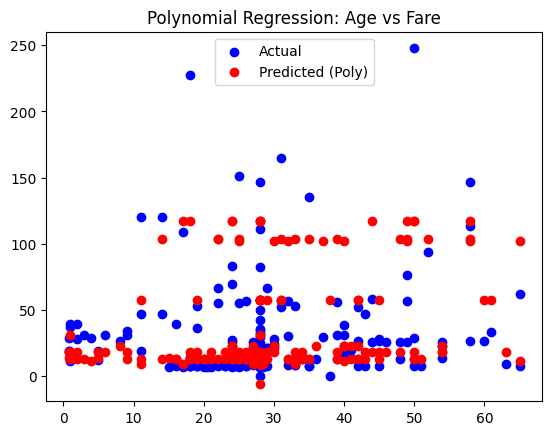

In [ ]:
# 5.4 Visualize Polynomial Cubic Fit (for 1 input feature)
plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y_pred_poly, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression: Age vs Fare")
plt.show()

## 5.4 Reflections:
1. What patterns does the cubic model seem to capture: Since this is based on case 1 and only features Age. There are no patterns but we can draw a conclusion that most people buy more affordable tickets.
2. Where does it perform well or poorly: It did poorly with the expensive tickets since there are only predicted dots and no actual dots above $145. It did well with the affordable tickets but those are almost a given due to nature of the business. 
3. Did the polynomial fit outperform linear regression: No quite the opposite it was the worst performing
Where (on the graph or among which kinds of data points) does it fit best: It only ft the cheaper affordable ticket and handled the expensive fares (outliers) poorly. Age has nothing to do with whether the person bought an expensive ticket or not.





In [ ]:
# 5.4 Model comparison report

def report(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  
    print(f"{name} R²: {r2_score(y_true, y_pred):.3f}")  
    print(f"{name} RMSE: {rmse:.2f}")                     
    print(f"{name} MAE: {mean_absolute_error(y_true, y_pred):.2f}\n") 


In [50]:
report("Linear", y4_test, y_pred_test4)
report("Ridge", y4_test, y_pred_ridge)
report("ElasticNet", y4_test, y_pred_elastic)
report("Polynomial", y4_test, y_pred_poly)


Linear R²: 0.346
Linear RMSE: 30.76
Linear MAE: 20.95

Ridge R²: 0.347
Ridge RMSE: 30.75
Ridge MAE: 20.92

ElasticNet R²: 0.347
ElasticNet RMSE: 30.75
ElasticNet MAE: 19.40

Polynomial R²: 0.001
Polynomial RMSE: 38.02
Polynomial MAE: 25.22



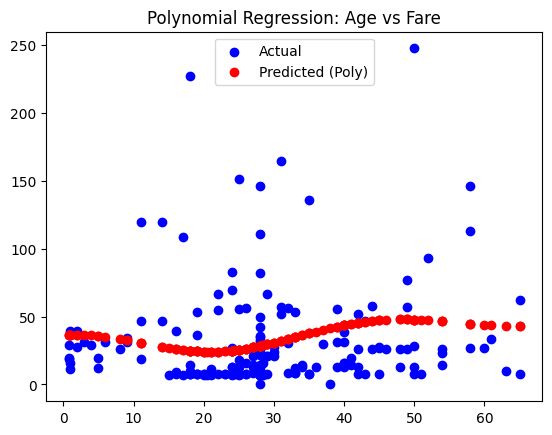

In [84]:
# 5.5 Visualize Higher Order Polynomial (for the same 1 input case)

 # Set up the poly inputs
poly = PolynomialFeatures(degree=8)
X_train_poly = poly.fit_transform(X1_train)
X_test_poly = poly.transform(X1_test)
 
# Use the poly inputs in the LR model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y1_train)
y_pred_poly = poly_model.predict(X_test_poly)

#plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y_pred_poly, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression: Age vs Fare")
plt.show()


# Section 6. Final Thoughts & Insights

6.1 Summarize Findings
What features were most useful?
Age, class and sex

What regression model performed best?
Elastic performed a little better than linear and ridge because it has a lowest MAE of  all models with a 19.40 and similar R2 of .347.

Linear R²: 0.346
Linear RMSE: 30.76
Linear MAE: 20.95

Ridge R²: 0.347
Ridge RMSE: 30.75
Ridge MAE: 20.92

ElasticNet R²: 0.347
ElasticNet RMSE: 30.75
ElasticNet MAE: 19.40

Polynomial R²: 0.001
Polynomial RMSE: 38.02
Polynomial MAE: 25.22

How did model complexity or regularization affect results?
The higher complexity made the model performance horrible with a score R2 of .001 meaning it tells us nothing about the fare and we might as well guess .Since Case 1 was used where only feature used was Age we can further conclude that age has no factor of the fare by itself.
 

6.2 Discuss Challenges
Was fare hard to predict? Why?
I say yes due to the complex structure. It seems like the more features included the more accurate the model became

Did skew or outliers impact the models?

Yes my RMSE and MAE are around 10 points apart. This indicates that the models made very few but wide range of wrong predictions since it uses takes the of average of absolute negative and positive errors.



 